---
title: "Marine's Data Wrangling"

format:

    html:

        embed-resources: true
---


# Wrangling and Summarizing Data

Read this notebook from top to bottom and fill in the code as you go. Work together and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

In addition to writing and running code, be sure to examine any output and interpret the results before moving on.

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas. However, you should generally try to find the simplest solution. In particular, use `groupby` whenever possible to streamline the code.

In [1]:
import pandas as pd

## Titanic data

In [2]:
df_titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")
df_titanic

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,0,NaN,restaurant staff


1\. Create a new variable "type" that takes values either "passenger" or "crew".

In [9]:
# YOUR CODE HERE.
df_titanic["type"] = "crew"
df_titanic.loc[df_titanic["pclass"].isin([1, 2, 3]), "type"] = "passenger"

df_titanic

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN,passenger
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN,passenger
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN,passenger
...,...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew,crew
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew,crew
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew,crew
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,0,NaN,restaurant staff,crew


2\. Find the proportion those onboard who were passengers and the proportion who were crew. Do this by creating a Series with these proportions.

In [10]:
df_titanic["type"].value_counts()

,count
type,
passenger,1317
crew,890


In [11]:
#proportion
df_titanic["type"].value_counts(normalize=True)

,proportion
type,
passenger,0.596738
crew,0.403262


3\. Note that "survived" is a categorical variable that has been one-hot encoded as a dummy (aka Bernoulli aka indicator) numerical variable with 1 = survived and 0 = not survived. (Check its dtype.) Find the proportion of those onboard who survived. You could do this with `value_counts` like for "type", but try a different way that takes advantage of the fact that "survived" is a numerical type. (Hint: what happens if you sum the values of a 1/0 variable? What happens if you take the mean of the values of a 1/0 variable?)

In [12]:
# check type
df_titanic.survived.dtype

dtype('int64')

In [13]:
df_titanic["survived"].mean()
# only considers who's 1, survived

np.float64(0.3221567739012234)

In [14]:
df_titanic["survived"].value_counts(normalize=True)

,proportion
survived,
0,0.677843
1,0.322157


4\. Create a crosstab (two-way table) summarizing the joint distribution of "survived" and "type". (Notice that we can treat the dummy variable "survived" as both a categorical variable and a numerical variable, whichever is convenient.)

In [15]:
# YOUR CODE HERE.
pd.crosstab(df_titanic["survived"], df_titanic["type"])

type,crew,passenger
survived,,
0,679,817
1,211,500


In [ ]:
pd.crosstab(df_titanic["survived"], df_titanic["type"], normalize=True)

type,passenger
survived,
0,0.620349
1,0.379651


5\. Compare the proportion of passengers who survived and the proportion of crew members who survived. Do this by creating a Series that contains these two proportions. Who was more likely to survive: passengers or crew?

Hint: there are a few ways of doing this, several of which avoid explicitly dividing. Can you take advantage of `groupby` and the fact that "survived" is a dummy variable?

In [19]:
# YOUR CODE HERE.
df_titanic.groupby("type")["survived"].mean()

,survived
type,
crew,0.237079
passenger,0.379651


ANS: passengers are more likely to survive

6\. The "gender" variable is coded only as "male" or "female". Among males only, compare the proportion of passengers who survived and the proportion of cew who survived. Among males, who was more likely to survive: passengers or crew? Then do the same thing among females only. Among females, who was more likely to survive: passengers or crew?

Do this by creating a Series that contains the 4 proportions you need. Hint: if you used `groupby` in the previous part you should only need a small change here.

In [18]:
# YOUR CODE HERE.
df_titanic.groupby(["gender", "type"])["survived"].mean()

gender  type     
female  crew         0.869565
        passenger    0.727468
male    crew         0.220300
        passenger    0.189189
Name: survived, dtype: float64

7\. Compare your answers to 5 and 6. What do you notice? Can you explain why this happens? Suggest an explanation and then create summaries of the data to support your explanation.

ANS: Passengers were more likely to survive, but when comparing males and females separately, crew members were more likely to survive in both groups. This happens because the passenger and crew groups have different proportions of males and females, and females had much higher survival rates overall.

## College Scorecard

The [College Scorecard](https://collegescorecard.ed.gov/) was an effort started by the U.S. Department of Education to help students make more informed choices about colleges. Data from 2022 is available at https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv


In [21]:
df_college = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv")

df_college

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0
6541,Pennsylvania State University-Penn State Brand...,Media,PA,NaN,61185.0


1\. What is the observational unit? Make a guess for how the earnings variable is computed.

ANS: The observational unit is Institution. I think the earnings variable is computed through averaging whatever data is provided to the universities about their Alumni earnings.

2\. Write code to find the California Polytechnic row in the data set!

In [22]:
# YOUR CODE HERE
df_college[df_college["City"] == "San Luis Obispo"]

,Institution,City,State,Undergraduates,Median Earnings
194,California Polytechnic State University-San Lu...,San Luis Obispo,CA,21090.0,85801.0
262,Cuesta College,San Luis Obispo,CA,6961.0,46197.0
4154,Central California School of Continuing Education,San Luis Obispo,CA,79.0,46527.0
4800,Laurus College,San Luis Obispo,CA,734.0,28846.0
6221,Columbia College - San Luis Obispo,San Luis Obispo,CA,NaN,44642.0


In [23]:
df_college[df_college["Institution"] == "California Polytechnic State University-San Luis Obispo"]
# or df_college[df_college["Institution"].str.contains()"California Polytechnic")

,Institution,City,State,Undergraduates,Median Earnings
194,California Polytechnic State University-San Lu...,San Luis Obispo,CA,21090.0,85801.0


3\. The data set contains information about the median earnings of students who attended each college, 10 years after they first enrolled. The earnings are taken directly from the W2 tax forms of all students who received federal financial aid.

Notice the earnings are missing (NaN). Create a subset data frame that only includes colleges with non-missing earnings. Use this subset to answer the remaining questions.

In [24]:
# YOUR CODE HERE.
df_college_earnings = df_college.dropna(subset = ["Median Earnings"])
df_college_earnings

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6537,Pennsylvania State University-Penn State Wilke...,Lehman,PA,NaN,61185.0
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0


4\. Summarize the earnings variable, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command! What is larger: the mean or the median? Why? Then create a histogram of the earnings variable.

In [25]:
df_college["Median Earnings"].describe()

,Median Earnings
count,5165.000000
mean,41128.801355
std,16185.531482
min,11085.000000
25%,29448.000000
50%,38696.000000
75%,49077.000000
max,129442.000000


<Axes: >

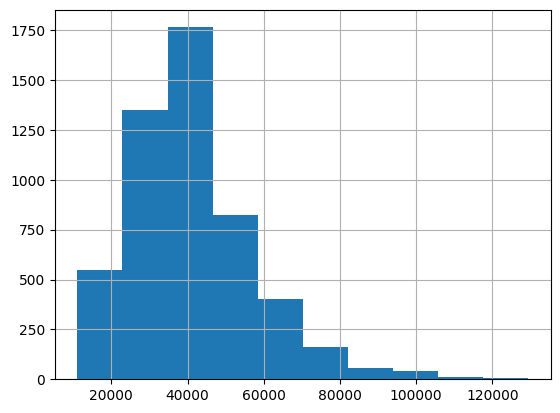

In [30]:
df_college["Median Earnings"].hist()

5\. Create a new column with the log of earnings, then create a histogram. How does the shape of the histogram of log earnings compare to earnings itself?

In [27]:
import numpy as np

/tmp/ipykernel_1296/4059977872.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_college_earnings["log Earnings"] = np.log(df_college_earnings["Median Earnings"])


<Axes: >

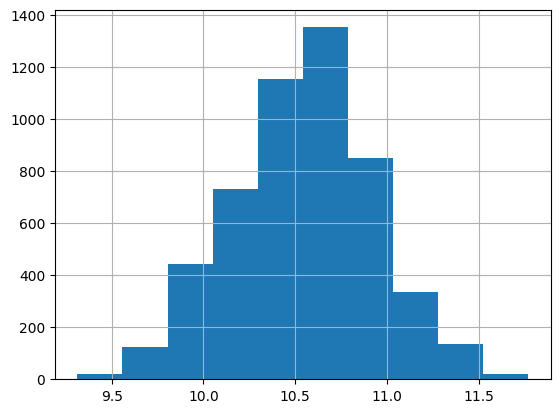

In [32]:
# YOUR CODE HERE

df_college_earnings["log Earnings"] = np.log(df_college_earnings["Median Earnings"])
df_college_earnings["log Earnings"].hist()

The second histogram is closer to a normal distribution in comparison to the first histogram that is rightly-skewed.

6\. The mean gives every college equal weight. But some colleges are tiny (e.g., San Francisco Conservatory, with 228 undergraduates), while others are large (e.g., Penn State, with 72229 undergraduates!).

If we are interested in what *students* earn, we might want to give more weight to colleges with more students. To do this, we can calculate a **weighted mean**:

$$ \sum_{i=1}^n w_i x_i. $$

In general, the weights $w_1, w_2, ..., w_n$ should all be non-negative and should add up to $1.0$. (For the usual mean, every observation gets equal weight, $1/n$.)

Calculate a weighted mean of earnings, using the undergraduate enrollments as weights. Do this by first adding a "weight" column to the data set (number of undegraduates for the college divided by the total number of undergraduates in the data set).

In [33]:
df_college_earnings["weight"] = df_college_earnings ["Undergraduates"] / df_college_earnings ["Undergraduates"].sum()

/tmp/ipykernel_1296/2150453947.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_college_earnings["weight"] = df_college_earnings ["Undergraduates"] / df_college_earnings ["Undergraduates"].sum()


In [34]:
df_college_earnings

,Institution,City,State,Undergraduates,Median Earnings,log Earnings,weight
0,Alabama A & M University,Normal,AL,5098.0,39059.0,10.572829,0.000368
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0,10.837756,0.000959
2,Amridge University,Montgomery,AL,251.0,37730.0,10.538211,0.000018
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0,10.949068,0.000531
4,Alabama State University,Montgomery,AL,3495.0,34018.0,10.434645,0.000252
...,...,...,...,...,...,...,...
6537,Pennsylvania State University-Penn State Wilke...,Lehman,PA,NaN,61185.0,11.021657,NaN
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0,11.021657,NaN
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0,11.021657,NaN
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0,11.021657,NaN


7\. Compute the mean of earnings for each state. Sort the states in descending order of mean earnings. Display the results in a bar chart.

In [35]:
# YOUR CODE HERE.
df_state = df_college.groupby("State")["Median Earnings"].mean().sort_values(ascending=False)
df_state

,Median Earnings
State,
MA,56633.768519
VT,53040.230769
RI,52605.947368
DC,51325.470588
CT,50771.413793
NH,49322.333333
NY,48752.694352
WA,47733.266667
PA,47607.290210


<Axes: xlabel='State'>

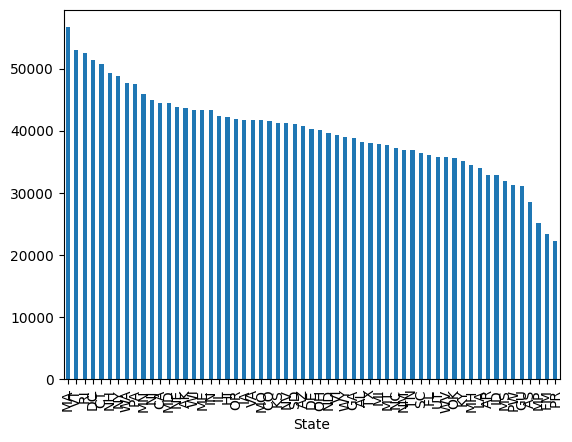

In [40]:
df_state.plot(kind = "bar")


8\. Repeat the previous part, but now compute a weighted mean of earnings for each state, using the number of undegraduate enrollments in the state as weights. (Hint: use `groupby` with `transform`.)

In [51]:
df_college["State Total"] = df_college.groupby("State")["Undergraduates"].transform("sum")

In [52]:
df_college["Weight"] = df_college["Undergraduates"] / df_college["State Total"]

In [53]:
df_college["Weighted Earnings"] = df_college["Median Earnings"] * df_college["Weight"]

In [54]:
df_state_weighted = df_college.groupby("State")["Weighted Earnings"].sum()

In [55]:
df_state_weighted = df_state_weighted.sort_values(ascending=False)
df_state_weighted

,Weighted Earnings
State,
DC,69714.602012
MA,64603.116013
RI,61011.031742
VT,58390.077060
CT,57231.975918
PA,56583.516058
NY,56554.697583
DE,55198.266807
WA,55052.969585


## Olympic Men's Gymnastics Data



The file https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

In [56]:
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")

df_gym

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


1\. Create a data frame

- With [Round, Year, Gymnast] as the (multi) index, and
- Containing only the six columns with the event scores, "Floor Exercise" through "Pommelled Horse"

In [65]:
df_gym.index.names

FrozenList(['Round', 'Year', 'Gymnast'])

In [66]:
df_gym = df_gym.loc[:, "Floor Exercise": "Pommelled Horse"]
df_gym

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva               15.100       15.500   
                   David Belyavsky            15.100       16.300   
                   Fabian HambÃ¼chen          15.133       15.833   
                   John Orozco                15.166       15.800   
                   Kristian Thomas            15.366       16.200   
...                                              ...          ...   
Final         2008 Daniel Keatings            14.850       15.800   
                   Thomas Bouhail             15.200       15.850   
                   José Luis Fuentes          14.175       15.250   
                   Dzmitry Savitski           13.725       15.900   
                   Chen Yibing                   NaN       15.900   

                                      Parallel Bars  Horizontal Bar   Rings  \
Round         Year Gymnast                                                    
Qualification 2012 Danell Leyva              15.333          15.866  14.600   
                   David Belyavsky           15.300          14.866  14.366   
                   Fabian HambÃ¼chen         15.300          15.633  14.766   
                   John Orozco               14.533          15.266  15.066   
                   Kristian Thomas           14.625          15.366  14.566   
...                                             ...             ...     ...   
Final         2008 Daniel Keatings           14.425          14.225  14.000   
                   Thomas Bouhail            14.425          14.475  13.650   
                   José Luis Fuentes         15.175          14.150  13.900   
                   Dzmitry Savitski          13.400          10.100  15.300   
                   Chen Yibing               14.950          12.975  16.650   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva                14.866  
                   David Belyavsky             14.900  
                   Fabian HambÃ¼chen           14.100  
                   John Orozco                 14.766  
                   Kristian Thomas             14.133  
...                                               ...  
Final         2008 Daniel Keatings             15.700  
                   Thomas Bouhail              13.400  
                   José Luis Fuentes           13.650  
                   Dzmitry Savitski            13.750  
                   Chen Yibing                 13.750  

[351 rows x 6 columns]

2\. Summarize the scores for each of the six events, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command!

In [67]:
# YOUR CODE HERE
df_gym.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,324.000000,318.000000,325.000000
mean,14.309133,14.976551,14.719288,14.082562,14.237799,13.816723
std,1.254009,0.959876,0.920044,1.299542,0.914523,1.242348
min,1.633000,11.766000,10.200000,0.000000,7.700000,0.000000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.854000,14.831000,14.566000
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


3\. There are 351 rows in the data frame. Why are the sample sizes different for each event, and not all equal to 351?

ANS: Conditions of the gymnasts change, certain ones likely did not make it to those rounds or qualifications.

4\. In the all around competition, each gymnast competes all six events, but this doesn't always happen (due to injury, etc). Therefore, there are some missing values in the data. Most of the missing values are coded as `NaN` but some are coded as 0. What would be a more appropriate way to code the missing values in this case: `NaN` or 0? Why?

NaN is more appropriate since a 0 means the gymnast competed and scored a zero. If the gymnast did not compete in the event, the score is missing, so it should be coded as NaN.

5\. Replace all scores of 0 in the data frame with `NaN`. (Note: It is possible to actually score a 0 on some events, e.g., if you do a vault but don't land feet first. But the few 0s in this data set are for people who didn't compete the event at all.)

In [70]:
import numpy as np

df_gym = df_gym.replace(0, np.nan)
df_gym

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva               15.100       15.500   
                   David Belyavsky            15.100       16.300   
                   Fabian HambÃ¼chen          15.133       15.833   
                   John Orozco                15.166       15.800   
                   Kristian Thomas            15.366       16.200   
...                                              ...          ...   
Final         2008 Daniel Keatings            14.850       15.800   
                   Thomas Bouhail             15.200       15.850   
                   José Luis Fuentes          14.175       15.250   
                   Dzmitry Savitski           13.725       15.900   
                   Chen Yibing                   NaN       15.900   

                                      Parallel Bars  Horizontal Bar   Rings  \
Round         Year Gymnast                                                    
Qualification 2012 Danell Leyva              15.333          15.866  14.600   
                   David Belyavsky           15.300          14.866  14.366   
                   Fabian HambÃ¼chen         15.300          15.633  14.766   
                   John Orozco               14.533          15.266  15.066   
                   Kristian Thomas           14.625          15.366  14.566   
...                                             ...             ...     ...   
Final         2008 Daniel Keatings           14.425          14.225  14.000   
                   Thomas Bouhail            14.425          14.475  13.650   
                   José Luis Fuentes         15.175          14.150  13.900   
                   Dzmitry Savitski          13.400          10.100  15.300   
                   Chen Yibing               14.950          12.975  16.650   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva                14.866  
                   David Belyavsky             14.900  
                   Fabian HambÃ¼chen           14.100  
                   John Orozco                 14.766  
                   Kristian Thomas             14.133  
...                                               ...  
Final         2008 Daniel Keatings             15.700  
                   Thomas Bouhail              13.400  
                   José Luis Fuentes           13.650  
                   Dzmitry Savitski            13.750  
                   Chen Yibing                 13.750  

[351 rows x 6 columns]

6\. Summarize the revised data. Which events tend to have the highest scores? The lowest? Which events have the greatest degree of variability in scores? The least?

In [71]:
# YOUR CODE HERE
df_gym.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,323.000000,318.000000,324.000000
mean,14.309133,14.976551,14.719288,14.126161,14.237799,13.859367
std,1.254009,0.959876,0.920044,1.037426,0.914523,0.977423
min,1.633000,11.766000,10.200000,9.433000,7.700000,10.666000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.858000,14.831000,14.574500
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


Highest - horse vault

Lowest - horizontal bar

Greatest degree of variablility in scores - floor exercise

Lowest degree of variablility in scores - rings

7\. Compute the correlation matrix. For which pairs of events is the correlation the highest? The lowest?

In [72]:
df_gym.corr()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Floor Exercise,1.000000,0.440092,0.351537,0.378685,0.494417,0.289385
Horse Vault,0.440092,1.000000,0.383301,0.500211,0.595005,0.367616
Parallel Bars,0.351537,0.383301,1.000000,0.557611,0.589963,0.481337
Horizontal Bar,0.378685,0.500211,0.557611,1.000000,0.491114,0.449014
Rings,0.494417,0.595005,0.589963,0.491114,1.000000,0.420985
Pommelled Horse,0.289385,0.367616,0.481337,0.449014,0.420985,1.000000


Highest - Rings and Horse Vault

Lowest - Pommelled Horse and Floor Exercise

8\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.

In [75]:
df_gym_standardize = (df_gym - df_gym.mean()) / df_gym.std()
df_gym_standardize

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.630671     0.545330   
                   David Belyavsky          0.630671     1.378771   
                   Fabian HambÃ¼chen        0.656987     0.892250   
                   John Orozco              0.683303     0.857870   
                   Kristian Thomas          0.842791     1.274591   
...                                              ...          ...   
Final         2008 Daniel Keatings          0.431311     0.857870   
                   Thomas Bouhail           0.710416     0.909960   
                   José Luis Fuentes       -0.106963     0.284879   
                   Dzmitry Savitski        -0.465812     0.962050   
                   Chen Yibing                   NaN     0.962050   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            0.667047        1.677073  0.396055   
                   David Belyavsky         0.631179        0.713149  0.140184   
                   Fabian HambÃ¼chen       0.631179        1.452479  0.577570   
                   John Orozco            -0.202477        1.098718  0.905610   
                   Kristian Thomas        -0.102482        1.195111  0.358877   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.319863        0.095273 -0.260025   
                   Thomas Bouhail         -0.319863        0.336254 -0.642738   
                   José Luis Fuentes       0.495316        0.022979 -0.369372   
                   Dzmitry Savitski       -1.433940       -3.880914  1.161481   
                   Chen Yibing             0.250762       -1.109632  2.637661   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.029884  
                   David Belyavsky           1.064669  
                   Fabian HambÃ¼chen         0.246191  
                   John Orozco               0.927574  
                   Kristian Thomas           0.279953  
...                                               ...  
Final         2008 Daniel Keatings           1.883148  
                   Thomas Bouhail           -0.469978  
                   José Luis Fuentes        -0.214203  
                   Dzmitry Savitski         -0.111893  
                   Chen Yibing              -0.111893  

[351 rows x 6 columns]

9\. The all around champion is whoever has the highest total score for the six events (in the finals). But who is the "all around standardized value champion"? Create a column that sums the standardized values for each athlete, then sort the data frame in descending order by that column. Note: you should NOT have to manually add six columns.

In [76]:
df_gym_standardize["Total"] = df_gym_standardize.sum(axis=1)

df_gym_standardize.sort_values("Total", ascending=False)

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                         
Final         2008 Yang Wei                0.750288     1.639221   
Qualification 2008 Yang Wei                0.869904     1.639221   
Final         2012 Kohei Uchimura          0.630671     1.343350   
Qualification 2008 Kim Dae-Eun             0.949648     1.118320   
                   Li Xiaopeng             0.630671     1.873626   
...                                             ...          ...   
              2020 Uche Eke               -1.177131    -1.608074   
                   David Huddleston       -1.496108    -1.017372   
                   Hung Yuan-Hsi          -0.858154    -2.094595   
                   David Rumbutis         -1.709025    -1.954993   
                   Jeremiah Loo           -0.964214    -2.615495   

                                     Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                     
Final         2008 Yang Wei               1.500703        0.625432  2.610324   
Qualification 2008 Yang Wei               0.685524        0.770020  2.172938   
Final         2012 Kohei Uchimura         0.658351        1.420669  1.197566   
Qualification 2008 Kim Dae-Eun            1.446357        0.480843  1.325501   
                   Li Xiaopeng            1.853947        1.227884  0.614748   
...                                            ...             ...       ...   
              2020 Uche Eke              -2.702358       -2.531420 -2.556304   
                   David Huddleston      -1.688276       -2.564194 -2.228264   
                   Hung Yuan-Hsi         -3.499060       -1.085534 -1.754793   
                   David Rumbutis        -3.245811       -1.535687 -3.321730   
                   Jeremiah Loo          -4.912036       -2.275016 -7.148862   

                                     Pommelled Horse      Total  
Round         Year Gymnast                                       
Final         2008 Yang Wei                 1.448331   8.574298  
Qualification 2008 Yang Wei                 1.601796   7.739403  
Final         2012 Kohei Uchimura           1.234504   6.485111  
Qualification 2008 Kim Dae-Eun              0.885627   6.206298  
                   Li Xiaopeng                   NaN   6.200877  
...                                              ...        ...  
              2020 Uche Eke                -1.016312 -11.591600  
                   David Huddleston        -2.925414 -11.919628  
                   Hung Yuan-Hsi           -3.164819 -12.456954  
                   David Rumbutis          -1.868553 -13.635800  
                   Jeremiah Loo            -1.630171 -19.545795  

[351 rows x 7 columns]

The all-around standardized value champion is Yang Wei in the 2008 final, with a total standardized value of 8.57.

10\. Compute the mean score for each event in each year. How do the means change over time? Why do you think this happened?

In [77]:
df_gym.groupby("Year").mean()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Year,,,,,,
2008,0.327842,0.901368,0.441794,0.421803,0.670003,0.398377
2012,0.148341,0.528981,-0.060929,0.231111,0.222698,-0.073863
2016,-0.139127,-0.500567,0.073687,0.115819,-0.039676,0.196386
2020,-0.372521,-0.969035,-0.518192,-0.760770,-0.857460,-0.559662


The means got lower and lower over time. I think this happened because of the scoring system and rules in gymnastics changed over time.

11\. Choose one event and for that event create a plot with a single panel that summarizes the distribution of scores for each of the four years. Describe what you see.

In [78]:
df_gym_plot = df_gym.reset_index()

/usr/local/lib/python3.13/dist-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 28 rows containing non-finite values.


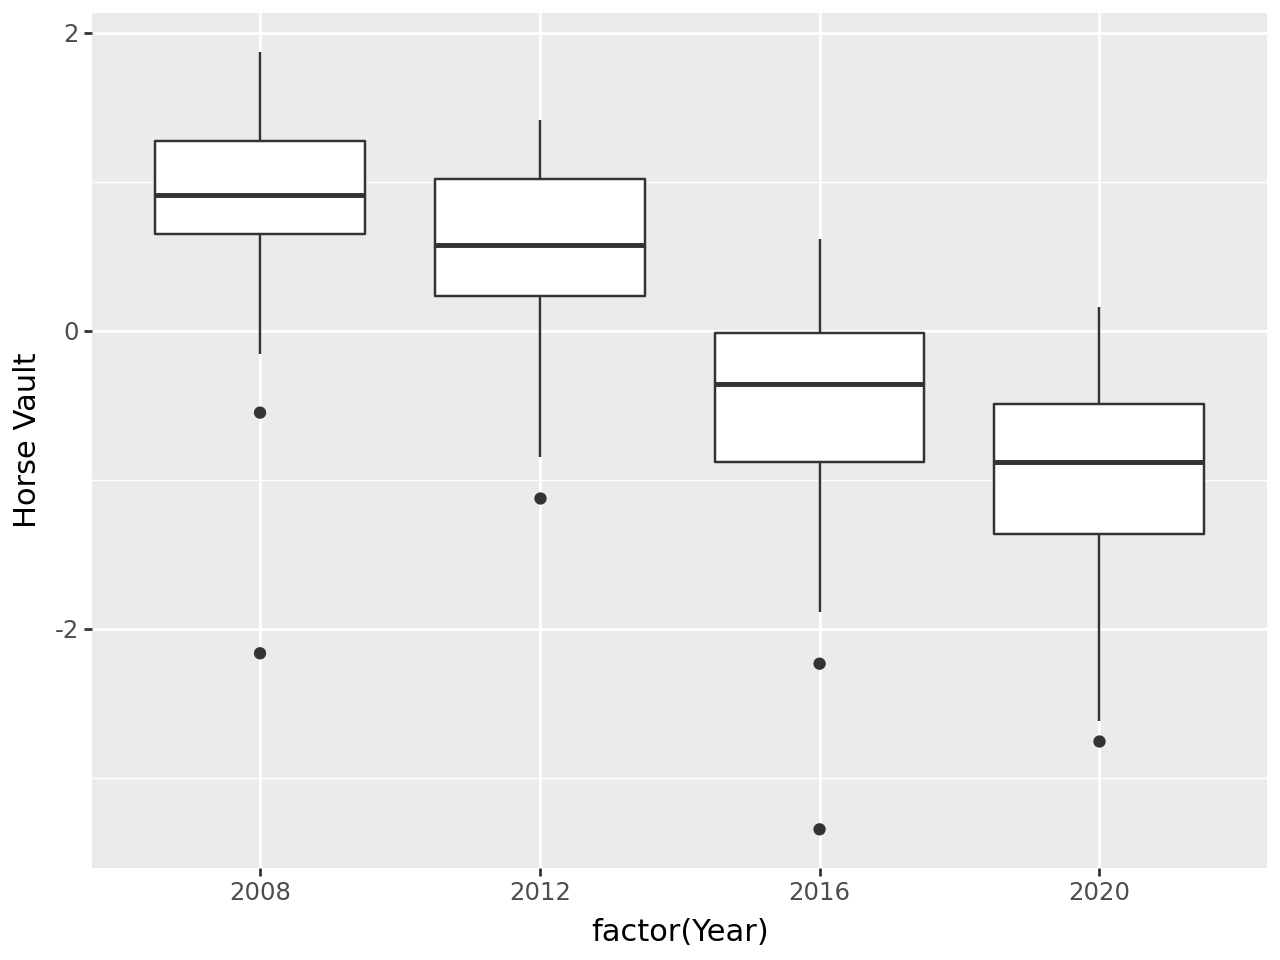

In [79]:
from plotnine import ggplot, aes, geom_boxplot

(
    ggplot(df_gym_plot,
        aes(
            x = "factor(Year)",
            y = "Horse Vault"
        ))
    + geom_boxplot()
)

12\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation *within each year*. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.


In [81]:
df_gym_year_standardize = (
    df_gym - df_gym.groupby("Year").transform("mean")
) / df_gym.groupby("Year").transform("std")

df_gym_year_standardize

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.753096     0.027915   
                   David Belyavsky          0.753096     1.451057   
                   Fabian HambÃ¼chen        0.794185     0.620298   
                   John Orozco              0.835273     0.561594   
                   Kristian Thomas          1.084294     1.273164   
...                                              ...          ...   
Final         2008 Daniel Keatings          0.098864    -0.076907   
                   Thomas Bouhail           0.365547     0.015192   
                   José Luis Fuentes       -0.415455    -1.089993   
                   Dzmitry Savitski        -0.758335     0.107290   
                   Chen Yibing                   NaN     0.107290   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            1.002995        1.708332  0.269011   
                   David Belyavsky         0.953577        0.569503 -0.128045   
                   Fabian HambÃ¼chen       0.953577        1.442985  0.550683   
                   John Orozco            -0.195024        1.025035  1.059729   
                   Kristian Thomas        -0.057251        1.138917  0.211319   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.896615       -0.385333 -1.098537   
                   Thomas Bouhail         -0.896615       -0.100954 -1.550593   
                   José Luis Fuentes       0.063005       -0.470647 -1.227696   
                   Dzmitry Savitski       -2.208096       -5.077583  0.580528   
                   Chen Yibing            -0.224881       -1.807227  2.324171   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.232874  
                   David Belyavsky           1.271729  
                   Fabian HambÃ¼chen         0.357497  
                   John Orozco               1.118595  
                   Kristian Thomas           0.395209  
...                                               ...  
Final         2008 Daniel Keatings           1.745577  
                   Thomas Bouhail           -1.020884  
                   José Luis Fuentes        -0.720182  
                   Dzmitry Savitski         -0.599901  
                   Chen Yibing              -0.599901  

[351 rows x 6 columns]

13\. If we standardize within each year, which athletes (and rounds and year) had the highest total standardized values? Basically repeat part 9 but with standardization within each year.

In [82]:
df_gym_year_standardize["Total"] = df_gym_year_standardize.sum(axis=1)

In [83]:
df_gym_year_standardize.sort_values("Total", ascending=False)

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                        
Final         2016 Oleh Verniaiev         0.520383     1.475149   
              2012 Kohei Uchimura         0.753096     1.390574   
Qualification 2020 Daiki Hashimoto        1.196662     1.341947   
Final         2020 Daiki Hashimoto        1.382156     1.070152   
Qualification 2016 Oleh Verniaiev         0.404528     0.837441   
...                                            ...          ...   
              2008 Mohamed Srour         -0.967872    -0.951845   
              2020 David Rumbutis        -2.337488    -1.549551   
              2016 KÃ©vin Crovetto       -0.739543    -1.954366   
              2008 Brandon O'Neill       -8.587414    -1.274190   
              2020 Jeremiah Loo          -1.034845    -2.587608   

                                    Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                    
Final         2016 Oleh Verniaiev        1.524323        0.534169  2.005141   
              2012 Kohei Uchimura        0.991015        1.405403  1.512779   
Qualification 2020 Daiki Hashimoto       1.007048        1.915265  0.443776   
Final         2020 Daiki Hashimoto       1.007048        1.802342  0.085413   
Qualification 2016 Oleh Verniaiev        1.600950        0.855432  1.822604   
...                                           ...             ...       ...   
              2008 Mohamed Srour        -3.519576       -0.499085 -2.809891   
              2020 David Rumbutis       -2.389868       -0.907808 -2.425281   
              2016 KÃ©vin Crovetto      -2.423146       -1.524613 -2.437804   
              2008 Brandon O'Neill      -0.288855             NaN       NaN   
              2020 Jeremiah Loo         -3.849770       -1.773927 -6.191859   

                                    Pommelled Horse      Total  
Round         Year Gymnast                                      
Final         2016 Oleh Verniaiev          1.554973   7.614139  
              2012 Kohei Uchimura          1.461432   7.514300  
Qualification 2020 Daiki Hashimoto         1.488590   7.393287  
Final         2020 Daiki Hashimoto         1.898201   7.245313  
Qualification 2016 Oleh Verniaiev          1.589606   7.110561  
...                                             ...        ...  
              2008 Mohamed Srour          -1.201306  -9.949575  
              2020 David Rumbutis         -1.310083 -10.920078  
              2016 KÃ©vin Crovetto        -2.362683 -11.442155  
              2008 Brandon O'Neill        -2.133483 -12.283942  
              2020 Jeremiah Loo           -1.071484 -16.509494  

[351 rows x 7 columns]